# Evaluating the model on the generated anomalies

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
# --- CONFIGURATION ---
DATA_PATH = 'data/final_models_input/train_dataset_with_anomalies.pkl' # Raw generated anomaly data
# SCALER_PATH = 'data/final_models_input/uni_scaler.pkl'
# MODEL_PATH = 'lstm_uni_autoencoder_model.pth'
SCALER_PATH = 'data/final_models_input/denoising_ae_scaler.pkl'
MODEL_PATH = 'denoising_autoencoder.pth'

# Model Config
SEQ_LEN = 1500 
EMBEDDING_DIM = 32
N_FEATURES = 4
BATCH_SIZE = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [4]:

# --- MODEL CLASS (Must match training) ---
# class Encoder(nn.Module):
#     def __init__(self, n_features, embedding_dim):
#         super(Encoder, self).__init__()
#         # 1. Unidirectional LSTM (bidirectional=False)
#         # We increase hidden_size to 128 to keep capacity high
#         self.lstm1 = nn.LSTM(input_size=n_features, hidden_size=256, 
#                              num_layers=1, batch_first=True, bidirectional=False)
        
#         self.lstm2 = nn.LSTM(input_size=256, hidden_size=embedding_dim, 
#                              num_layers=1, batch_first=True, bidirectional=False)
        
#     def forward(self, x):
#         x, (_, _) = self.lstm1(x)
#         _, (hidden, _) = self.lstm2(x)
#         return hidden[-1]

# class Decoder(nn.Module):
#     def __init__(self, seq_len, input_dim, n_features):
#         super(Decoder, self).__init__()
#         self.seq_len = seq_len
        
#         # Decoder matches Encoder
#         self.lstm1 = nn.LSTM(input_size=input_dim, hidden_size=256, 
#                              num_layers=1, batch_first=True, bidirectional=False)
        
#         self.lstm2 = nn.LSTM(input_size=256, hidden_size=256, 
#                              num_layers=1, batch_first=True, bidirectional=False)
        
#         self.output_layer = nn.Linear(256, n_features)

#     def forward(self, x):
#         x = x.unsqueeze(1).repeat(1, self.seq_len, 1)
#         x, _ = self.lstm1(x)
#         x, _ = self.lstm2(x)
#         x = self.output_layer(x)
#         return x
    
# class RecurrentAutoencoder(nn.Module):
#     def __init__(self, seq_len, n_features, embedding_dim=64):
#         super(RecurrentAutoencoder, self).__init__()
#         self.encoder = Encoder(n_features, embedding_dim)
#         self.decoder = Decoder(seq_len, embedding_dim, n_features)

#     def forward(self, x):
#         latent = self.encoder(x)
#         reconstruction = self.decoder(latent)
#         return reconstruction

class Encoder(nn.Module):
    def __init__(self, n_features=4, embedding_dim=32): # Reduced embedding to 32
        super(Encoder, self).__init__()
        # Layer 1: 4 -> 64
        self.lstm1 = nn.LSTM(input_size=n_features, hidden_size=64, 
                             num_layers=1, batch_first=True, bidirectional=False)
        # Layer 2: 64 -> 32 (Tight Bottleneck)
        self.lstm2 = nn.LSTM(input_size=64, hidden_size=embedding_dim, 
                             num_layers=1, batch_first=True, bidirectional=False)
        
    def forward(self, x):
        x, _ = self.lstm1(x)
        _, (hidden, _) = self.lstm2(x)
        return hidden[-1]

class Decoder(nn.Module):
    def __init__(self, seq_len, input_dim=32, n_features=4):
        super(Decoder, self).__init__()
        self.seq_len = seq_len
        # Layer 1: 32 -> 64
        self.lstm1 = nn.LSTM(input_size=input_dim, hidden_size=64, 
                             num_layers=1, batch_first=True, bidirectional=False)
        # Layer 2: 64 -> 64
        self.lstm2 = nn.LSTM(input_size=64, hidden_size=64, 
                             num_layers=1, batch_first=True, bidirectional=False)
        # Output: 64 -> 4
        self.output_layer = nn.Linear(64, n_features)

    def forward(self, x):
        x = x.unsqueeze(1).repeat(1, self.seq_len, 1)
        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)
        x = self.output_layer(x)
        return x

class DenoisingAutoencoder(nn.Module):
    def __init__(self, seq_len=300, n_features=4, embedding_dim=32):
        super(DenoisingAutoencoder, self).__init__()
        self.encoder = Encoder(n_features, embedding_dim)
        self.decoder = Decoder(seq_len, embedding_dim, n_features)

    def forward(self, x):
        return self.decoder(self.encoder(x))


### Top-K scoring

In [5]:
# --- TOP-K SCORING FUNCTION ---
# --- 1. The Top-K Scoring Function ---
def calculate_top_k_score(input_tensor, recon_tensor, k=30):
    """
    Computes anomaly score based on the worst K time steps.
    """
    # 1. Absolute Error: (Batch, 300, 4)
    error = torch.abs(input_tensor - recon_tensor)
    
    # 2. Sum over Features (Important!)
    # If only 1 sensor fails (Drift), averaging over 4 sensors divides error by 4.
    # Summing ensures a single broken sensor raises the alarm.
    # Shape: (Batch, 300)
    error_sum_features = torch.sum(error, dim=2)
    
    # 3. Find the Top K errors over Time
    # values shape: (Batch, K)
    top_k_values, _ = torch.topk(error_sum_features, k=k, dim=1)
    
    # 4. Average the Top K
    # Shape: (Batch,)
    return torch.mean(top_k_values, dim=1)

# --- 2. The Evaluation Loop ---
def evaluate_with_top_k(model, loader, device):
    model.eval()
    all_scores = []
    
    # K=30 is 10% of your 300-step sequence. Ideally tuned for detecting
    # short spikes (Hammer) and medium tails (Leaks).
    K_STEPS = 150 
    
    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(device)
            recon = model(x)
            
            # Use Top-K Metric
            batch_scores = calculate_top_k_score(x, recon, k=K_STEPS)
            
            all_scores.extend(batch_scores.cpu().numpy())
            
    return np.array(all_scores)

In [8]:
# --- EVALUATION LOGIC ---
def evaluate_synthetic_performance():
    # 1. Load Data
    print("Loading Data & Scaler...")
    with open(DATA_PATH, 'rb') as f:
        data = pickle.load(f)
        X_raw = data['X']
        y_labels = data['y'] # 0=Normal, 1=Leak, 2=Offset, 3=Drift
        
    with open(SCALER_PATH, 'rb') as f:
        scaler = pickle.load(f)

    # 2. Preprocess
    print("Preprocessing...")
    N, T, F = X_raw.shape
    X_flat = X_raw.reshape(-1, F)
    X_scaled = scaler.transform(X_flat).reshape(N, T, F)
    # X_downsampled = X_scaled[:, ::5, :] # 1500 -> 300
    X_downsampled = X_scaled  # Using full length 1500
    
    tensor_x = torch.FloatTensor(X_downsampled).to(device)
    loader = DataLoader(TensorDataset(tensor_x), batch_size=BATCH_SIZE, shuffle=False)

    # 3. Load Model
    print("Running Inference...")
    model = DenoisingAutoencoder(SEQ_LEN, N_FEATURES, EMBEDDING_DIM).to(device)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()

    # # 4. Calculate Scores
    # all_scores = []
    # with torch.no_grad():
    #     for batch in loader:
    #         x = batch[0]
    #         recon = model(x)
    #         loss = torch.mean(torch.abs(x - recon), dim=(1, 2)) # MAE per sample
    #         all_scores.extend(loss.cpu().numpy())
    
    # all_scores = np.array(all_scores)

    # Define K (10% of 300 is a good starting point)
    K_STEPS = 30 

    # 4. Calculate Scores (IMPROVED METRIC)
    all_scores = []
    with torch.no_grad():
        for batch in loader:
            x = batch[0]
            recon = model(x)
            
            # # Absolute Error Map: (Batch, 300, 4)
            # error_map = torch.abs(x - recon)
            
            # # STRATEGY: MAX OVER TIME, SUM OVER FEATURES
            # # 1. Find the worst moment in time for each feature
            # max_error_per_feature = torch.max(error_map, dim=1)[0] # Shape: (Batch, 4)
            
            # # 2. Sum the errors of the 4 features
            # # We sum instead of mean, so 1 bad sensor doesn't get diluted
            # score = torch.sum(max_error_per_feature, dim=1)
            score = calculate_top_k_score(x, recon, k=K_STEPS)
            all_scores.extend(score.cpu().numpy())

    all_scores = np.array(all_scores)

    # 5. Determine Threshold (Using only Normal Data)
    # Strategy: Threshold = Mean + 3 StdDev of Normal Data
    normal_indices = np.where(y_labels == 0)[0]
    normal_scores = all_scores[normal_indices]
    
    threshold = np.mean(normal_scores) + 3 * np.std(normal_scores)
    # Alternatively: Use 99th percentile to be safer against outliers
    # threshold = np.percentile(normal_scores, 99)
    
    print(f"\n--- THRESHOLD SETTING ---")
    print(f"Normal Mean Score: {np.mean(normal_scores):.5f}")
    print(f"Normal Max Score:  {np.max(normal_scores):.5f}")
    print(f"Calculated Threshold: {threshold:.5f}")

    # 6. Updated Fault Mapping
    # Based on the order in 'generate_comprehensive_anomalies'
    fault_names = {
        0: "Normal", 
        1: "Seal Leakage", 
        2: "Delayed Closure", 
        3: "Sensor Offset", 
        4: "Sensor Drift",
        5: "Water Hammer",
        6: "Stick-Slip/Jerky",
        7: "PID Hunting",
        8: "Signal Dropout"
    }
    
    # Define Colors for plotting
    colors = {
        0: 'blue',      # Normal
        1: 'red',       # Leak
        2: 'purple',    # Delay
        3: 'orange',    # Offset
        4: 'green',     # Drift
        5: 'brown',     # Hammer
        6: 'magenta',   # Jerky
        7: 'black',      # PID Hunting
        8: 'cyan'       # Signal Dropout
    }

    # 7. Print Table
    print(f"\n{'Fault Type':<20} | {'Detected':<10} | {'Avg Score':<10}")
    print("-" * 50)
    
    unique_labels = np.sort(np.unique(y_labels))
    
    for lbl in unique_labels:
        idxs = np.where(y_labels == lbl)[0]
        sc = all_scores[idxs]
        
        # Detection Rate
        detected_count = np.sum(sc > threshold)
        rate = detected_count / len(sc) * 100
        
        name = fault_names.get(lbl, f"Type {lbl}")
        print(f"{name:<20} | {rate:>8.1f}% | {np.mean(sc):.5f}")

    # 8. Visualization (Histograms)
    plt.figure(figsize=(12, 6))
    
    # Plot Normal first to be at the back
    lbl = 0
    plt.hist(all_scores[y_labels == lbl], bins=50, alpha=0.3, 
             label=fault_names[lbl], color=colors[lbl], density=True)

    # Plot Anomalies
    for lbl in unique_labels:
        if lbl == 0: continue
        plt.hist(all_scores[y_labels == lbl], bins=50, alpha=0.5, 
                 label=fault_names.get(lbl, f"Type {lbl}"), 
                 color=colors.get(lbl, 'gray'), density=True)
    
    plt.axvline(threshold, color='black', linestyle='--', linewidth=2, label='Threshold')
    plt.title(f"Anomaly Score Distribution (Top-{K_STEPS} Metric)")
    plt.xlabel("Reconstruction Error Score")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


Loading Data & Scaler...
Preprocessing...
Running Inference...


C:\Users\shrey\AppData\Local\Temp\ipykernel_23308\3553731405.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=d


--- THRESHOLD SETTING ---
Normal Mean Score: 0.40239
Normal Max Score:  1.09102
Calculated Threshold: 0.57278

Fault Type           | Detected   | Avg Score 
--------------------------------------------------
Normal               |      1.2% | 0.40239
Seal Leakage         |      4.2% | 0.46518
Delayed Closure      |      1.0% | 0.41335
Sensor Offset        |    100.0% | 1.11766
Sensor Drift         |      2.2% | 0.49458
Water Hammer         |     93.4% | 0.65041
Stick-Slip/Jerky     |      1.4% | 0.40242
PID Hunting          |      1.2% | 0.40239
Signal Dropout       |      1.8% | 0.43563


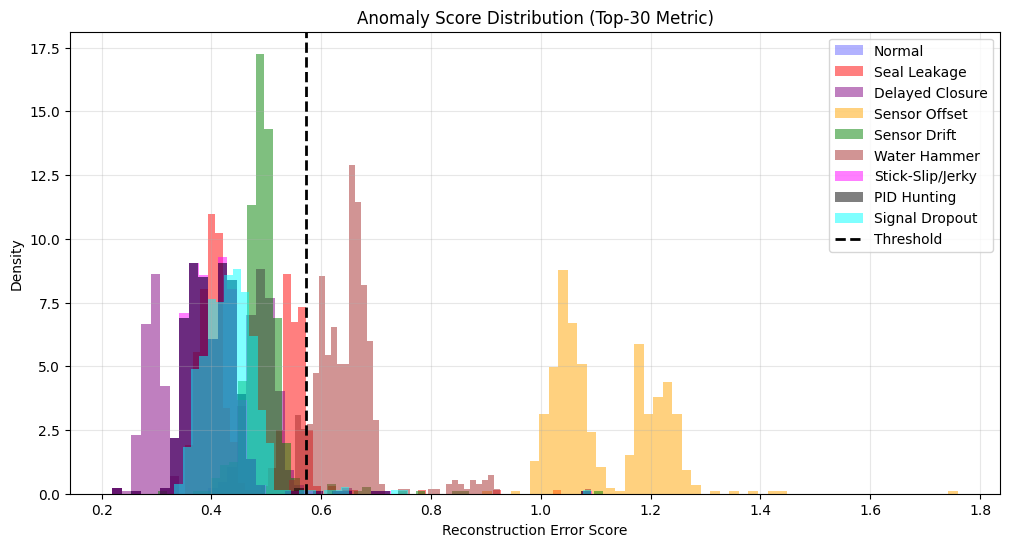

In [9]:
# Run Evaluation
evaluate_synthetic_performance()